In [1]:
import os 
import numpy as np 
import matplotlib.pyplot as plt

from pyfluids import Fluid, FluidsList, Input


In [2]:
# Material Properties

water = Fluid(FluidsList.Water)
# Set state for water
water = water.with_state(
    Input.temperature(8),  # Temperature in Celsius
    Input.pressure(101325)   # Pressure in Pascals (≈1 atm)
)

# Calculate properties
rho_water = water.density  # Density in kg/m^3
cp_water = water.specific_heat  # Specific heat capacity in J/(kg·K)
k_water = water.conductivity # Thermal conductivity in W/(m·K)

ethane = Fluid(FluidsList.Ethane)
# Set state for ethane
ethane_bulk = ethane.with_state(
    Input.temperature(-180),  # Temperature in Celsius
    Input.pressure(101325)   # Pressure in Pascals (≈1 atm)
)

rho_ethane = ethane_bulk.density  # Density in kg/m^3
cp_ethane = ethane_bulk.specific_heat  # Specific heat capacity in J/(kg·K)
k_ethane = ethane_bulk.conductivity  # Thermal conductivity in W/(m·K)
mu_ethane = ethane_bulk.dynamic_viscosity # Dynamic viscosity in Pa·s

ethane_wall_temperature = ethane.with_state(
    Input.temperature(18),  # Wall temperature in Celsius
    Input.pressure(101325)   # Pressure in Pascals (≈1 atm)
)
mu_ethane_wall = ethane_wall_temperature.dynamic_viscosity  # Dynamic viscosity at wall temperature in Pa·s
print(mu_ethane, mu_ethane_wall)
correction_factor = (mu_ethane / mu_ethane_wall) ** 0.14
print(f"Correction factor: {correction_factor}")

0.0011363924387245475 9.148097214593444e-06
Correction factor: 1.9642088297216462


In [12]:
# Geometrical Parameters
thickness_of_water = 300e-9 # 200nm thickness
characteristic_length_for_h = 1.5e-3 # 1.5mm characteristic length for heat transfer
# Physical Parameters
velocity = 1 # m/s
T_grid = 293 #K 
T_ethane = 80 #K



In [13]:
# Step 1: Compute heat transfer coefficient 
# 1A: Reynolds number
Re = (rho_ethane * velocity * characteristic_length_for_h) / mu_ethane
# 1B: Prandtl number
Pr = (cp_ethane * mu_ethane) / k_ethane
# 1C: Nusselt number
# Taken from Eq. 4.76, Basic Heat And Mass Transfer: A. F. Mills 
# Original reference: https://aiche.onlinelibrary.wiley.com/doi/epdf/10.1002/aic.690180219 Eq 37
Nu = 2 + (0.4 * Re**(1/2) + 0.06 * Re**(2/3)) * Pr**(0.4) * correction_factor
# 1D: Heat transfer coefficient
h = (Nu * k_ethane) / characteristic_length_for_h
print(f"Heat transfer coefficient: {h:.2f} W/(m^2·K)")


# Calculate h_comsol 
denominator = np.power(1+np.power((0.0468/Pr),2/3),0.25)
numerator = 0.3387 * np.power(Re,0.5) * np.power(Pr,1/3)
factor = 2 * k_ethane / characteristic_length_for_h

h_comsol = factor * numerator / denominator * correction_factor
print('Heat transfer coefficient from comsol = ', h_comsol)

Heat transfer coefficient: 14800.75 W/(m^2·K)
Heat transfer coefficient from comsol =  14237.72921714206


In [17]:
# Compute temperature response 
t_start = 0
t_end = 10e-3 # 10ms
times = np.linspace(t_start, t_end, 1000)  # Time points for simulation

area = np.pi * thickness_of_water**2 * 4 
volume = 4/3 * np.pi * thickness_of_water**3  # Volume of the water layer
# time constant 
tau = (rho_water * cp_water * volume) / (h * area)
# Temperature response
T_response = T_grid + (T_ethane - T_grid) * (1-np.exp(-times / tau))


Text(0.5, 1.0, 'Temperature Response of Water Layer')

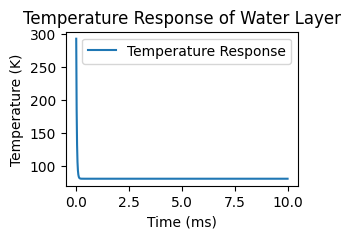

In [18]:
import seaborn as sns 
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(x=times * 1e3, y=T_response, label='Temperature Response')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Temperature (K)')
ax.set_title('Temperature Response of Water Layer')


